# Linear Regression Model - Course Baseline

**Purpose:** Establish baseline performance using Linear Regression (from Lecture 3) on the enhanced master dataset.

**Model Type:** Linear Regression (Course Concept - Lecture 3)
- Simple, interpretable baseline
- Assumes linear relationships between features and demand
- Fast training, provides coefficient interpretability

**Dataset:** Master dataset with 36 features
- 109,056 hourly records (June 2013 - Nov 2025)
- Features: Weather, temporal, engineered (lags, degree days), HOEP prices, solar, holidays

**Expected Performance:** RMSE ~1,500-1,800 MW

**Why this baseline:**
- Simplest course concept to start with
- Provides interpretable feature importance through coefficients
- Sets benchmark for more complex models to beat

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Plot settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Load master dataset
print("Loading master dataset...")
df = pd.read_csv("../../../02_Datasets/processed/master_dataset_complete.csv",
                 parse_dates=['DateTime', 'Date'])

print(f"✓ Data loaded successfully")
print(f"\nDataset shape: {df.shape}")
print(f"Date range: {df['DateTime'].min()} to {df['DateTime'].max()}")
print(f"Total features: {len(df.columns)}")

# Show first few rows
print(f"\nFirst 3 rows:")
df.head(3)

Loading master dataset...
✓ Data loaded successfully

Dataset shape: (109056, 36)
Date range: 2013-06-01 00:00:00 to 2025-11-09 00:00:00
Total features: 36

First 3 rows:


,DateTime,Date,Hour,Year,Month,DayOfWeek,DayOfYear,IsWeekend,Market Demand,Ontario Demand,...,Hour_Sin,Hour_Cos,Month_Sin,Month_Cos,HOEP,GHI,DNI,DHI,IsHoliday,Holiday_Name
0,2013-06-01 00:00:00,2013-06-01,1,2013,6,5,152,1,15908,13731,...,0.258819,0.965926,1.224647e-16,-1.0,13.86,4.4316,1.219,3.3902,0,NaN
1,2013-06-01 01:00:00,2013-06-01,2,2013,6,5,152,1,15126,13143,...,0.500000,0.866025,1.224647e-16,-1.0,12.73,4.4316,1.219,3.3902,0,NaN
2,2013-06-01 02:00:00,2013-06-01,3,2013,6,5,152,1,14652,12778,...,0.707107,0.707107,1.224647e-16,-1.0,11.21,4.4316,1.219,3.3902,0,NaN


In [2]:
print("Preparing data for modeling...")
print("="*70)

# Check missing values
print(f"\nMissing values:")
print(df.isna().sum()[df.isna().sum() > 0])

# Select feature columns (exclude non-numeric and identifier columns)
exclude_cols = ['DateTime', 'Date', 'Holiday_Name']
feature_cols = [col for col in df.columns if col not in exclude_cols + ['Ontario Demand', 'Market Demand']]

print(f"\n\nFeature columns ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

# Target variable
target_col = 'Ontario Demand'

print(f"\nTarget variable: {target_col}")

Preparing data for modeling...

Missing values:
Demand_Lag_1h           1
Demand_Lag_24h         24
Demand_Lag_168h       168
HOEP                 4613
GHI                    24
DNI                  2425
DHI                  2425
Holiday_Name       106272
dtype: int64


Feature columns (31):
   1. Hour
   2. Year
   3. Month
   4. DayOfWeek
   5. DayOfYear
   6. IsWeekend
   7. Temp (°C)
   8. Dew Point Temp (°C)
   9. Rel Hum (%)
  10. Wind Dir (10s deg)
  11. Wind Spd (km/h)
  12. Visibility (km)
  13. Stn Press (kPa)
  14. Demand_Lag_1h
  15. Demand_Lag_24h
  16. Demand_Lag_168h
  17. Demand_RollingAvg_24h
  18. Demand_RollingAvg_168h
  19. HDD
  20. CDD
  21. Temp_x_Hour
  22. Temp_Squared
  23. Hour_Sin
  24. Hour_Cos
  25. Month_Sin
  26. Month_Cos
  27. HOEP
  28. GHI
  29. DNI
  30. DHI
  31. IsHoliday

Target variable: Ontario Demand


In [3]:
print("Creating feature matrix (X) and target vector (y)...")

# Create X (features) and y (target)
X = df[feature_cols].copy()
y = df[target_col].copy()

print(f"\nOriginal shapes:")
print(f"  X: {X.shape}")
print(f"  y: {y.shape}")

# Drop rows where lag features are missing (first 168 hours)
# These are critical features we can't impute
mask_valid = df['Demand_Lag_168h'].notna()
X = X[mask_valid]
y = y[mask_valid]

print(f"\nAfter removing rows with missing lag features:")
print(f"  X: {X.shape}")
print(f"  y: {y.shape}")
print(f"  Rows dropped: {(~mask_valid).sum()}")

# For remaining missing values (HOEP, solar), use forward fill then backward fill
print(f"\nHandling remaining missing values...")
print(f"  Missing before: {X.isna().sum().sum()}")

X = X.fillna(method='ffill').fillna(method='bfill')

print(f"  Missing after: {X.isna().sum().sum()}")

print(f"\n✓ Data preparation complete")
print(f"  Final X shape: {X.shape}")
print(f"  Final y shape: {y.shape}")

Creating feature matrix (X) and target vector (y)...

Original shapes:
  X: (109056, 31)
  y: (109056,)

After removing rows with missing lag features:
  X: (108888, 31)
  y: (108888,)
  Rows dropped: 168

Handling remaining missing values...
  Missing before: 9487
  Missing after: 0

✓ Data preparation complete
  Final X shape: (108888, 31)
  Final y shape: (108888,)


In [4]:
print("Splitting data into train/validation/test sets...")
print("="*70)

# Split strategy: 77% train, 8% validation, 15% test
# Using time-based split (chronological)

n = len(X)
train_size = int(0.77 * n)
val_size = int(0.08 * n)

# Train set: first 77%
X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]

# Validation set: next 8%
X_val = X.iloc[train_size:train_size+val_size]
y_val = y.iloc[train_size:train_size+val_size]

# Test set: remaining 15%
X_test = X.iloc[train_size+val_size:]
y_test = y.iloc[train_size+val_size:]

print(f"Training set:   {X_train.shape[0]:,} samples ({X_train.shape[0]/n*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]:,} samples ({X_val.shape[0]/n*100:.1f}%)")
print(f"Test set:       {X_test.shape[0]:,} samples ({X_test.shape[0]/n*100:.1f}%)")

print(f"\n✓ Data split complete")

Splitting data into train/validation/test sets...
Training set:   83,843 samples (77.0%)
Validation set: 8,711 samples (8.0%)
Test set:       16,334 samples (15.0%)

✓ Data split complete


In [5]:
print("Training Linear Regression model...")
print("="*70)

# Initialize and train model
model = LinearRegression()
model.fit(X_train, y_train)

print("✓ Model trained successfully!")

# Make predictions on all sets
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

# Calculate metrics for each set
def calculate_metrics(y_true, y_pred, set_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n{set_name}:")
    print(f"  RMSE: {rmse:,.2f} MW")
    print(f"  MAE:  {mae:,.2f} MW")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")
    
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}

# Evaluate on all sets
train_metrics = calculate_metrics(y_train, y_train_pred, "Training Set")
val_metrics = calculate_metrics(y_val, y_val_pred, "Validation Set")
test_metrics = calculate_metrics(y_test, y_test_pred, "Test Set")

print("\n" + "="*70)
print("LINEAR REGRESSION RESULTS:")
print(f"  Test RMSE: {test_metrics['RMSE']:,.2f} MW")
print(f"  Test R²:   {test_metrics['R2']:.4f}")
print("="*70)

Training Linear Regression model...
✓ Model trained successfully!

Training Set:
  RMSE: 400.37 MW
  MAE:  310.49 MW
  R²:   0.9713
  MAPE: 2.00%

Validation Set:
  RMSE: 387.81 MW
  MAE:  296.42 MW
  R²:   0.9674
  MAPE: 1.88%

Test Set:
  RMSE: 413.25 MW
  MAE:  315.26 MW
  R²:   0.9704
  MAPE: 1.94%

LINEAR REGRESSION RESULTS:
  Test RMSE: 413.25 MW
  Test R²:   0.9704


Creating visualizations...


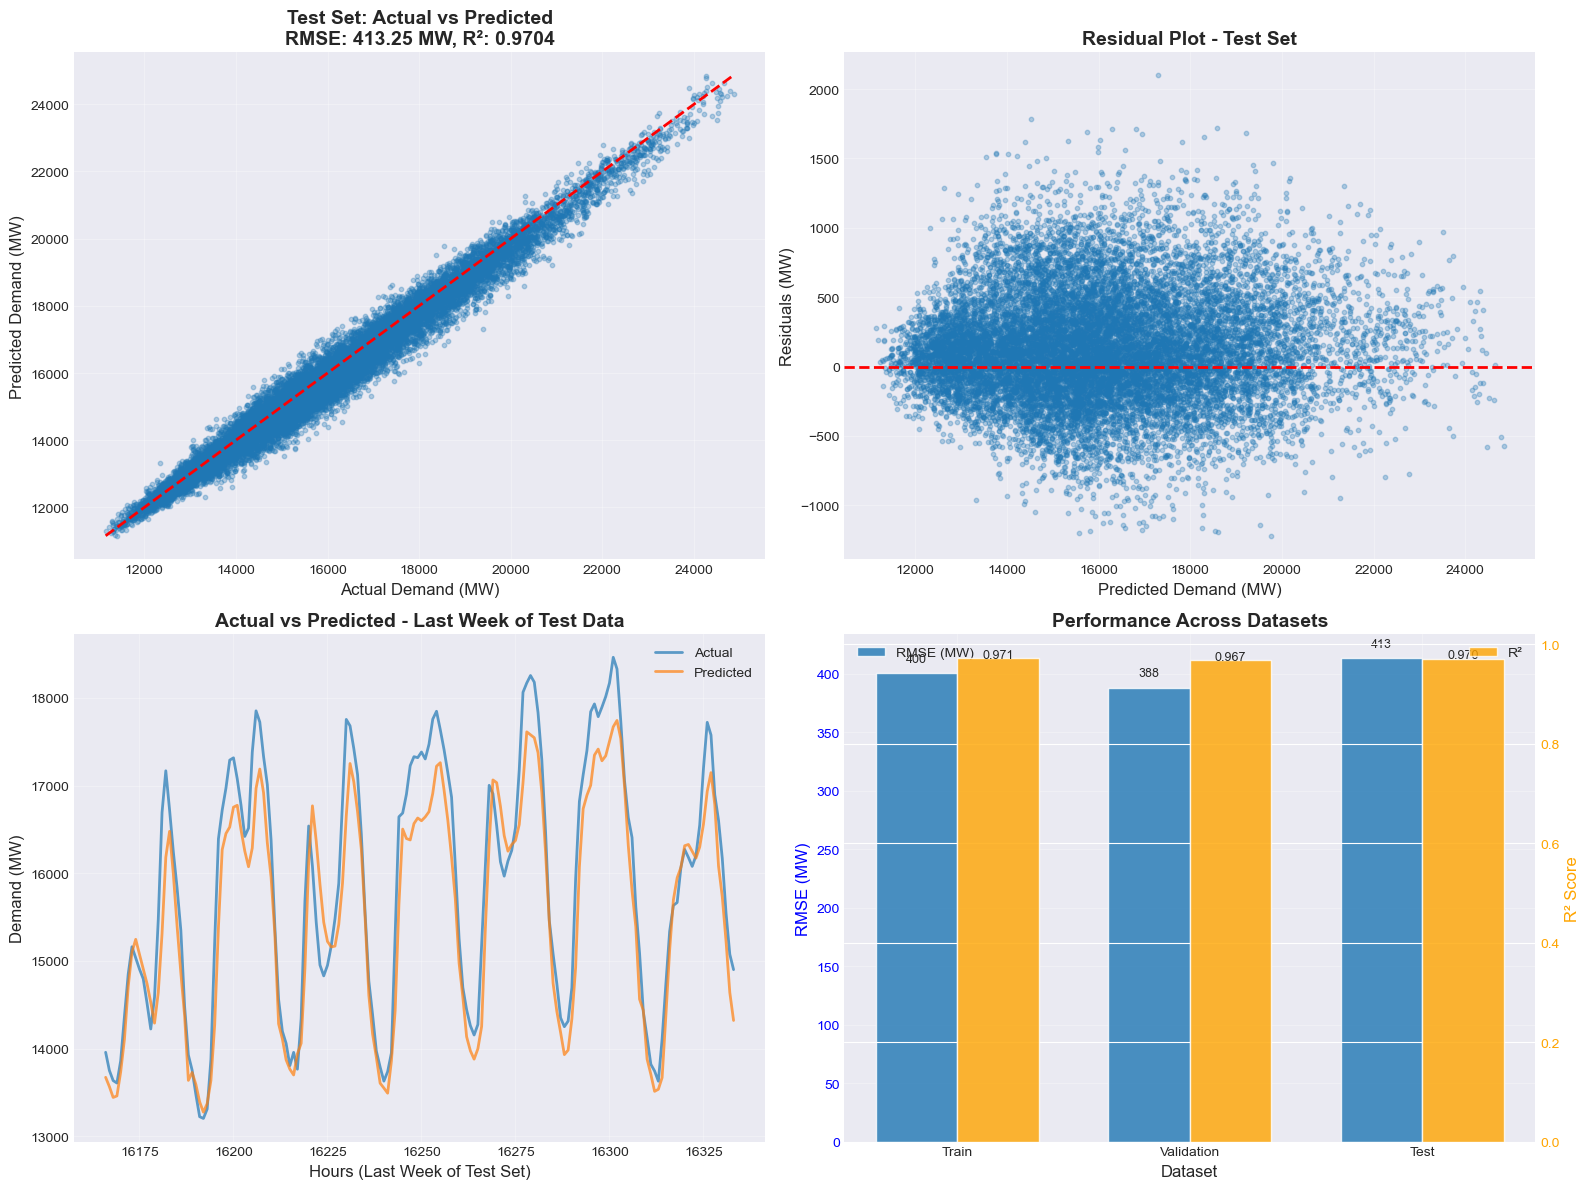


✓ Visualizations created and saved!


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Creating visualizations...")

# Set up the plot style
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Scatter plot - Test Set Actual vs Predicted
ax1 = axes[0, 0]
ax1.scatter(y_test, y_test_pred, alpha=0.3, s=10)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax1.set_xlabel('Actual Demand (MW)', fontsize=12)
ax1.set_ylabel('Predicted Demand (MW)', fontsize=12)
ax1.set_title(f'Test Set: Actual vs Predicted\nRMSE: {test_metrics["RMSE"]:.2f} MW, R²: {test_metrics["R2"]:.4f}', 
              fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# 2. Residuals plot
ax2 = axes[0, 1]
residuals = y_test - y_test_pred
ax2.scatter(y_test_pred, residuals, alpha=0.3, s=10)
ax2.axhline(y=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Predicted Demand (MW)', fontsize=12)
ax2.set_ylabel('Residuals (MW)', fontsize=12)
ax2.set_title('Residual Plot - Test Set', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. Time series comparison (sample of test set)
ax3 = axes[1, 0]
sample_size = 168  # 1 week
sample_indices = range(len(y_test) - sample_size, len(y_test))
ax3.plot(sample_indices, y_test.iloc[-sample_size:].values, label='Actual', linewidth=2, alpha=0.7)
ax3.plot(sample_indices, y_test_pred[-sample_size:], label='Predicted', linewidth=2, alpha=0.7)
ax3.set_xlabel('Hours (Last Week of Test Set)', fontsize=12)
ax3.set_ylabel('Demand (MW)', fontsize=12)
ax3.set_title('Actual vs Predicted - Last Week of Test Data', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

# 4. Metrics comparison across sets
ax4 = axes[1, 1]
sets = ['Train', 'Validation', 'Test']
rmse_values = [train_metrics['RMSE'], val_metrics['RMSE'], test_metrics['RMSE']]
r2_values = [train_metrics['R2'], val_metrics['R2'], test_metrics['R2']]

x = np.arange(len(sets))
width = 0.35

bars1 = ax4.bar(x - width/2, rmse_values, width, label='RMSE (MW)', alpha=0.8)
ax4_twin = ax4.twinx()
bars2 = ax4_twin.bar(x + width/2, r2_values, width, label='R²', alpha=0.8, color='orange')

ax4.set_xlabel('Dataset', fontsize=12)
ax4.set_ylabel('RMSE (MW)', fontsize=12, color='blue')
ax4_twin.set_ylabel('R² Score', fontsize=12, color='orange')
ax4.set_title('Performance Across Datasets', fontsize=14, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(sets)
ax4.tick_params(axis='y', labelcolor='blue')
ax4_twin.tick_params(axis='y', labelcolor='orange')
ax4.legend(loc='upper left')
ax4_twin.legend(loc='upper right')
ax4.grid(True, alpha=0.3)

# Add value labels on bars
for i, (rmse, r2) in enumerate(zip(rmse_values, r2_values)):
    ax4.text(i - width/2, rmse + 10, f'{rmse:.0f}', ha='center', fontsize=9)
    ax4_twin.text(i + width/2, r2 + 0.001, f'{r2:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../../../04_Presentation/model_results/01_linear_regression/performance.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualizations created and saved!")

In [7]:
# Save model results to a CSV for later comparison
results_summary = {
    'Model': 'Linear Regression',
    'Train_RMSE': train_metrics['RMSE'],
    'Train_R2': train_metrics['R2'],
    'Val_RMSE': val_metrics['RMSE'],
    'Val_R2': val_metrics['R2'],
    'Test_RMSE': test_metrics['RMSE'],
    'Test_R2': test_metrics['R2'],
    'Test_MAE': test_metrics['MAE'],
    'Test_MAPE': test_metrics['MAPE']
}

# Save to CSV
import os
results_dir = '../../../04_Presentation/model_results/06_comparison/'
os.makedirs(results_dir, exist_ok=True)

results_df = pd.DataFrame([results_summary])
results_df.to_csv(f'{results_dir}model_comparison.csv', index=False)

print("✓ Results saved!")
print(f"\nLinear Regression Summary:")
print(f"  Test RMSE: {test_metrics['RMSE']:.2f} MW")
print(f"  Test R²: {test_metrics['R2']:.4f}")
print(f"  Test MAE: {test_metrics['MAE']:.2f} MW")
print(f"  Test MAPE: {test_metrics['MAPE']:.2f}%")

✓ Results saved!

Linear Regression Summary:
  Test RMSE: 413.25 MW
  Test R²: 0.9704
  Test MAE: 315.26 MW
  Test MAPE: 1.94%
